In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn import datasets
import plotly.express as px

In [2]:
np.random.seed(42)
mean = [0, 0]
cov = [[3,2], [2,2]]
var = np.random.multivariate_normal(cov=cov,mean=mean,size=200)
pd.DataFrame(var)

,0,1
0,-0.779843,-0.725035
1,-1.710971,-0.056423
2,0.489592,0.185568
3,-2.971226,-1.675159
4,0.569237,0.900239
...,...,...
195,1.311965,1.437601
196,1.476209,2.691156
197,-1.794320,-1.795107
198,2.332247,2.958321


In [3]:
var[:,0]

array([-0.77984256, -1.7109707 ,  0.48959165, -2.97122622,  0.56923681,
        0.96991616,  0.37232934,  3.13291389,  1.57697817,  2.10410746,
       -2.37531795,  0.46690187,  0.87123107,  1.78452439,  1.12999928,
        0.25813425,  0.45373603, -0.88720856,  0.44695249,  2.15569151,
       -1.31299097,  0.31738506,  2.78232697,  0.34467994,  0.13997584,
       -0.38865358,  0.89029624, -2.11511254,  1.5387695 , -0.95519174,
        0.88231316,  2.34989155, -1.92049678, -0.28771276, -0.34590537,
       -1.23513098, -0.57727736,  4.07524173, -0.0246932 ,  0.6554559 ,
        0.22428044, -2.27674156,  1.56550929, -1.67498313,  0.68266059,
       -0.55814376,  1.31538064,  1.25646613, -0.60487791,  0.08698547,
        2.55409335,  0.90386269,  0.10686402, -3.24640717, -0.40323226,
        3.2409267 , -1.10515806,  0.20094702,  0.53466809, -2.23027608,
       -0.96107617, -1.79025939, -1.88053926,  1.89826613,  0.0374086 ,
        2.58249843,  1.59532925,  0.91619479,  1.44979347, -0.86

<function matplotlib.pyplot.show(close=None, block=None)>

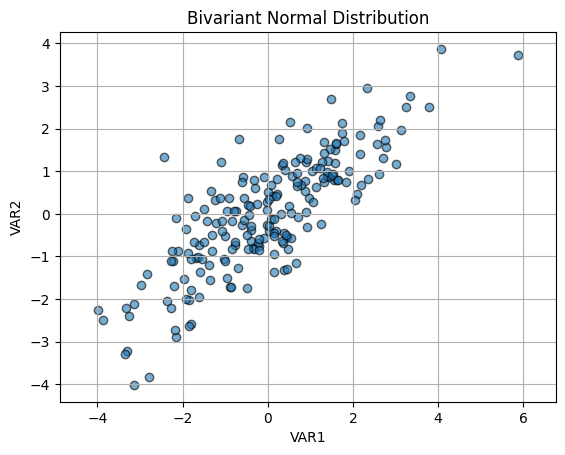

In [4]:
plt.figure()
plt.scatter(var[:,0], var[:,1], ec='k',alpha=0.6)
plt.title("Bivariant Normal Distribution")
plt.ylabel("VAR2")
plt.xlabel("VAR1")
plt.axis("equal")
plt.grid(True)
plt.show

In [5]:
pca = PCA(n_components=2)
var_pca = pca.fit_transform(var)

<function matplotlib.pyplot.show(close=None, block=None)>

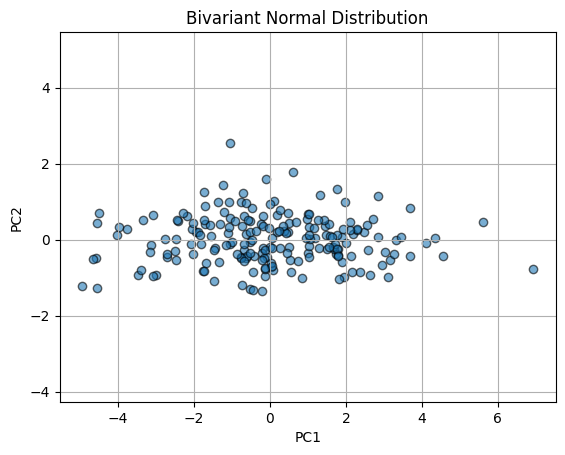

In [6]:
plt.scatter(var_pca[:,0], var_pca[:,1], ec='k',alpha=0.6)
plt.title("Bivariant Normal Distribution")
plt.ylabel("PC2")
plt.xlabel("PC1")
plt.axis("equal")
plt.grid(True)
plt.show

In [7]:
comp = pca.components_
comp

array([[ 0.78215821,  0.62307987],
       [-0.62307987,  0.78215821]])

In [8]:
pca.explained_variance_ratio_

array([0.9111946, 0.0888054])

In [9]:
projection_1 = np.dot(var, comp[0])
projection_2 = np.dot(var, comp[1])

In [10]:
x_1 = projection_1 * comp[0][0]
y_1 = projection_1 * comp[0][1]
x_2 = projection_2 * comp[1][0]
y_2 = projection_2 * comp[1][1]

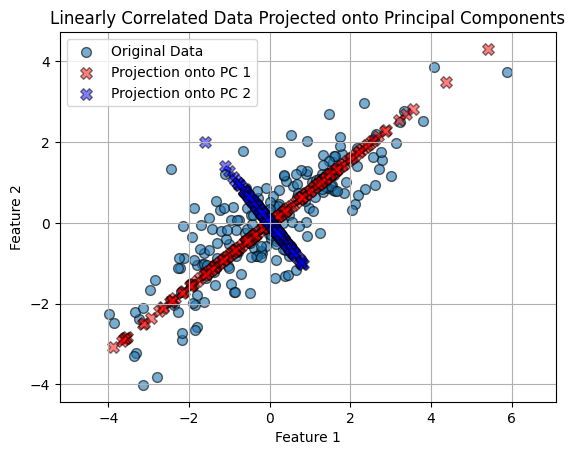

In [11]:
plt.figure()
plt.scatter(var[:, 0], var[:, 1], label='Original Data', ec='k', s=50, alpha=0.6)

plt.scatter(x_1, y_1, c='r', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 1')
plt.scatter(x_2, y_2, c='b', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 2')
plt.title('Linearly Correlated Data Projected onto Principal Components')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [12]:
projection_1_pca = np.dot(var_pca, (1,0))
projection_2_pca = np.dot(var_pca, (0,1))
x_1_pca = projection_1_pca * 1
y_1_pca = projection_1_pca * 0
x_2_pca = projection_2_pca * 0
y_2_pca = projection_2_pca * 1

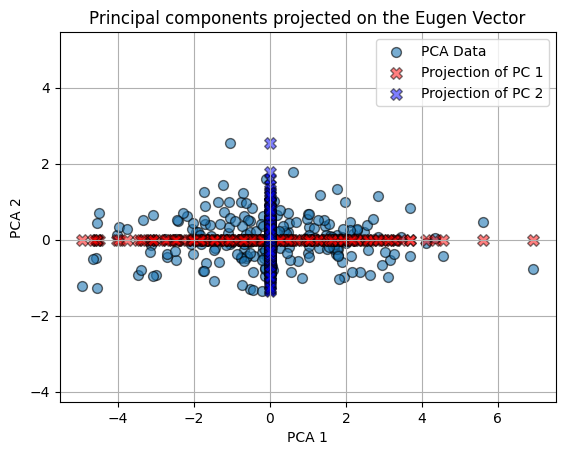

In [13]:
plt.figure()
plt.scatter(var_pca[:, 0], var_pca[:, 1], label='PCA Data', ec='k', s=50, alpha=0.6)

plt.scatter(x_1_pca, y_1_pca, c='r', ec='k', marker='X', s=70, alpha=0.5, label='Projection of PC 1')
plt.scatter(x_2_pca, y_2_pca, c='b', ec='k', marker='X', s=70, alpha=0.5, label='Projection of PC 2')
plt.title('Principal components projected on the Eugen Vector')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [14]:
iris = datasets.load_iris()
dat = iris.data
targ = iris.target
targ_na = iris.target_names

scaler = StandardScaler()
dat_sc = scaler.fit_transform(dat)

In [15]:
i_pca = PCA(n_components=2)
dat_pca = i_pca.fit_transform(dat_sc)

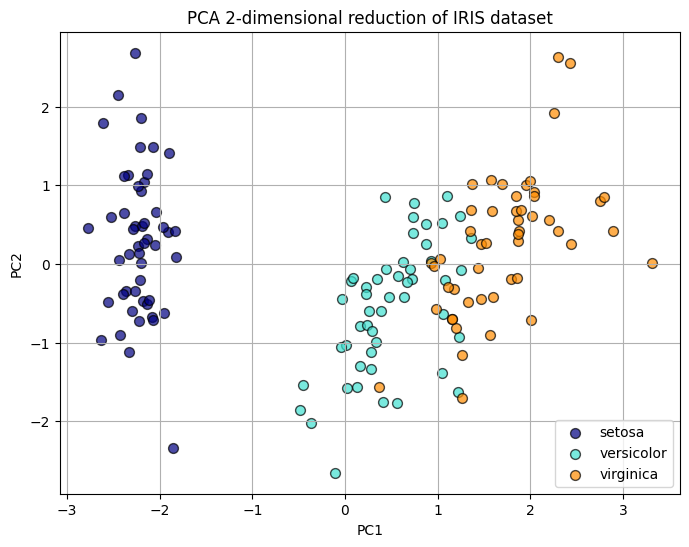

In [16]:
plt.figure(figsize=(8,6))

colors = ['navy', 'turquoise', 'darkorange']
lw = 1

for color, i, name in zip(colors, [0, 1, 2], targ_na):
    plt.scatter(dat_pca[targ == i, 0], dat_pca[targ == i, 1], color=color, s=50, ec='k',alpha=0.7, lw=lw,
                label=name)

plt.title('PCA 2-dimensional reduction of IRIS dataset')
plt.xlabel("PC1",)
plt.ylabel("PC2",)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.grid(True)
plt.show()

In [23]:
i_pca.explained_variance_ratio_.sum()

np.float64(0.9581320720000166)

In [28]:
a_pca = PCA(n_components=4)
dat_a_pca = a_pca.fit_transform(dat_sc)
a_pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

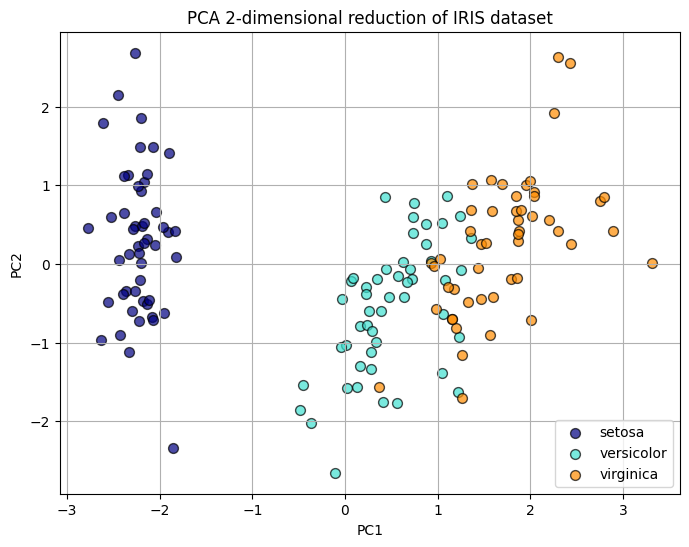

In [29]:
plt.figure(figsize=(8,6))

colors = ['navy', 'turquoise', 'darkorange']
lw = 1

for color, i, name in zip(colors, [0, 1, 2], targ_na):
    plt.scatter(dat_a_pca[targ == i, 0], dat_a_pca[targ == i, 1], color=color, s=50, ec='k',alpha=0.7, lw=lw,
                label=name)

plt.title('PCA 2-dimensional reduction of IRIS dataset')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.grid(True)
plt.show()

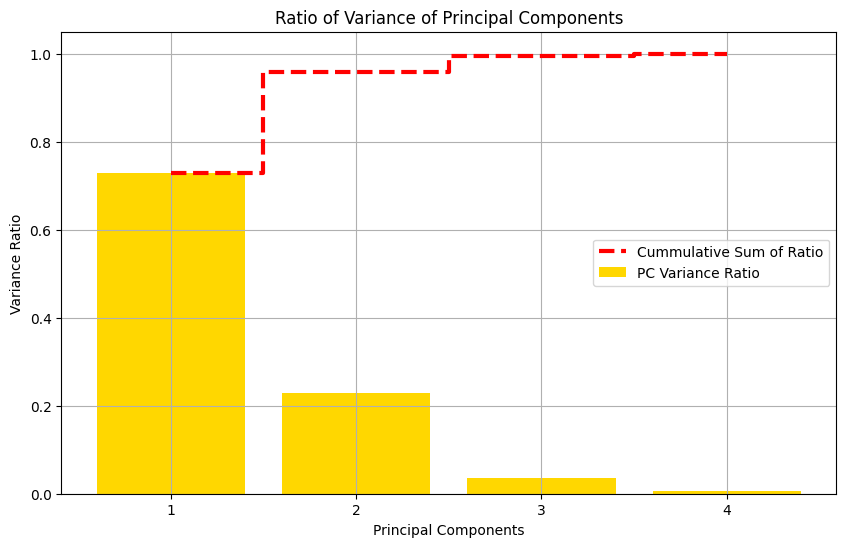

In [41]:
var_ratio = a_pca.explained_variance_ratio_
plt.figure(figsize=(10,6))
plt.bar(x=range(1, len(var_ratio)+1), height=var_ratio, align="center", alpha=1, color="gold", label="PC Variance Ratio")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.title("Ratio of Variance of Principal Components")
cum_var=np.cumsum(var_ratio)
plt.step(range(1,5), cum_var, where="mid", linestyle="--", lw=3, c="r", label="Cummulative Sum of Ratio")
plt.xticks(range(1,5))
plt.grid(True)
plt.legend()

plt.show()

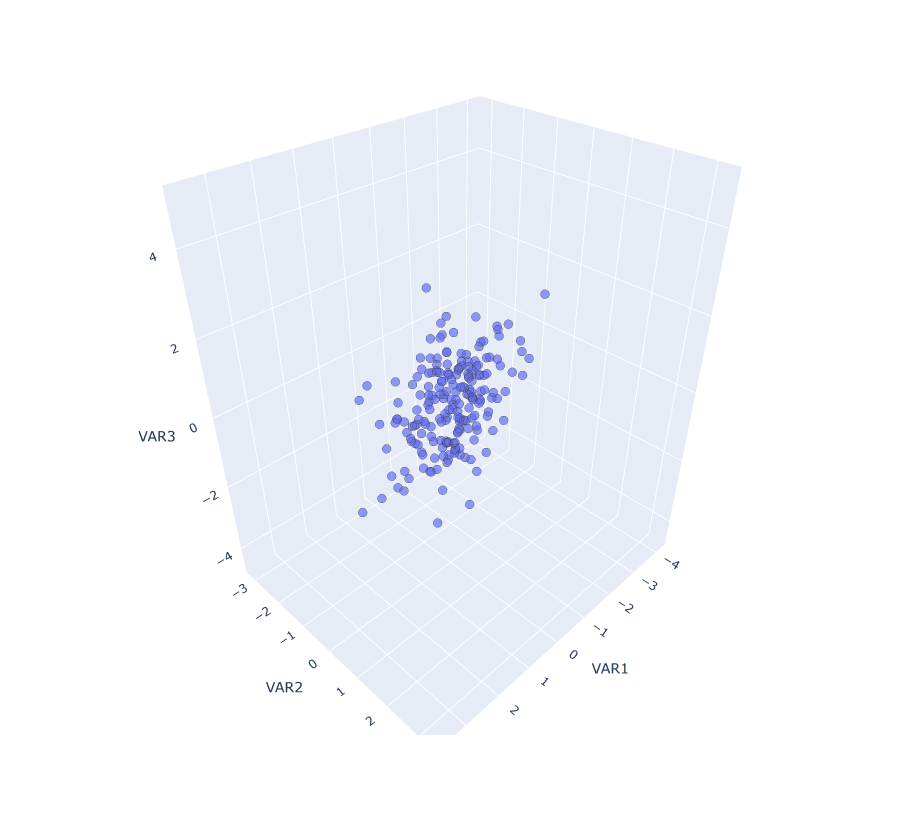

In [45]:
fig = px.scatter_3d(var, x=0, y=1, z=2, opacity=0.7)

fig.update_traces(marker=dict(size=5, line=dict(width=.25)), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800, scene=dict(
        xaxis=dict(title='VAR1'),
        yaxis=dict(title='VAR2'),
        zaxis=dict(title='VAR3')
    ))
fig.show()